## Обучение без учителя. Задача кластеризации

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.datasets import make_classification, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.metrics.cluster import rand_score

### Генерация датасетов при помощи `make_classification`, `make_blobs`

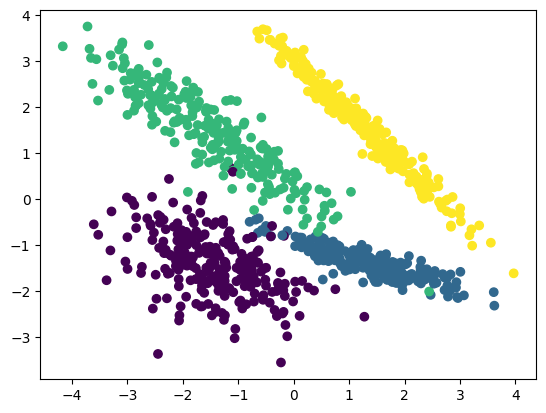

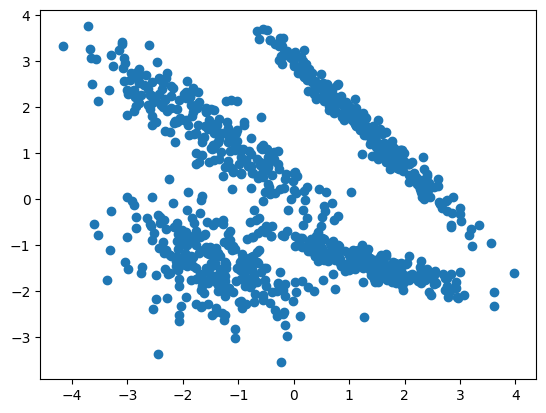

In [2]:
x_1, y_1 = make_classification(
    n_samples=1000,
    n_features=2,
    n_classes=4,
    n_clusters_per_class=1,
    class_sep=1.4,
    n_redundant = 0,
    flip_y=0, 
    random_state=17
)

plt.scatter(x_1[:, 0], x_1[:, 1], c=y_1)
plt.show()

plt.scatter(x_1[:, 0], x_1[:, 1])
plt.show()

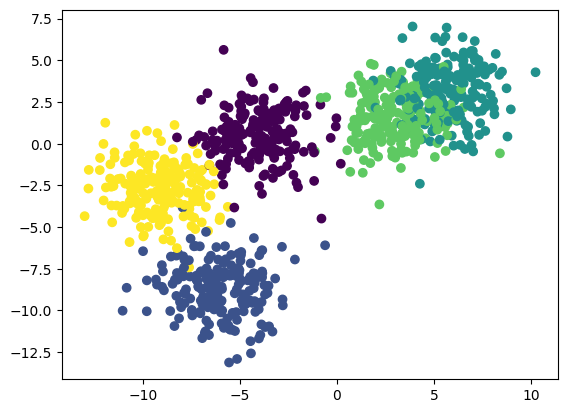

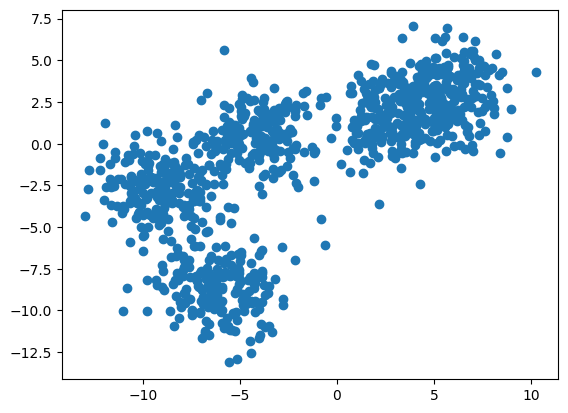

In [3]:
x_2, y_2 = make_blobs(
    n_samples=1000,
    n_features=2, 
    centers=5,
    shuffle=True,
    random_state=17,
    cluster_std=1.5
)

plt.scatter(x_2[:, 0], x_2[:, 1], c=y_2)
plt.show()

plt.scatter(x_2[:, 0], x_2[:, 1])
plt.show()

### Загрузка предобработанного датасета

In [4]:
data = pd.read_csv('../data/credit_card_fraud_filtered.csv')
y_3 = data['fraud']
x_3 = data.drop('fraud', axis=1)

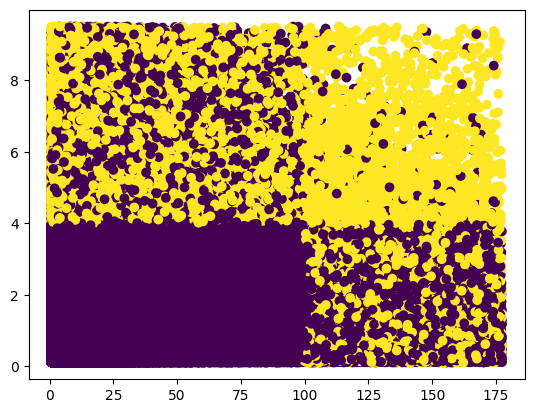

In [5]:
plt.scatter(x_3.values[:, 0], x_3.values[:, 2], c=y_3)
plt.show()

In [6]:
results = []
dataset_names = ['make_classification', 'make_blobs', 'credit_card_fraud']

### Стандартизация признаков

In [7]:
x_3_col = x_3.columns
x_1 = StandardScaler().fit_transform(x_1)
x_2 = StandardScaler().fit_transform(x_2)
x_3 = StandardScaler().fit_transform(x_3)

x_1 = pd.DataFrame(x_1, columns=['feature_1', 'feature_2'])
x_2 = pd.DataFrame(x_2, columns=['feature_1', 'feature_2'])
x_3 = pd.DataFrame(x_3, columns=x_3_col)

### k-Means

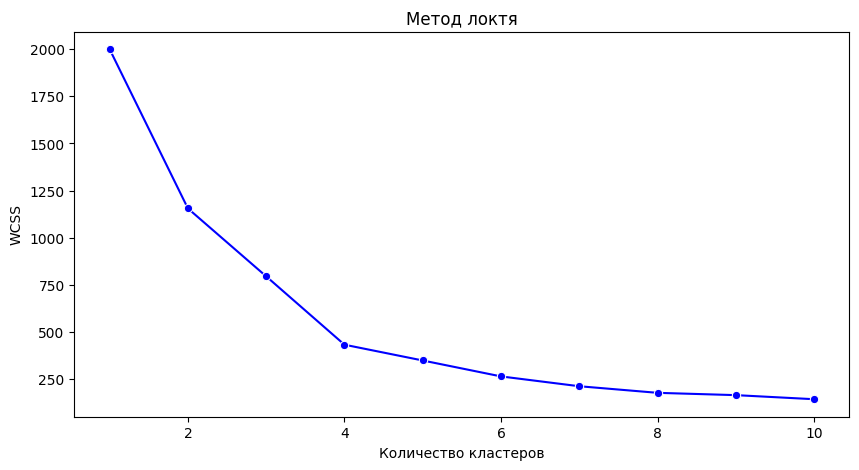

Наилучшее число кластеров 4
silhouette_score = 0.4899
rand_score = 0.8923
Кластер 0: число наблюдений 223
Кластер 1: число наблюдений 267
Кластер 2: число наблюдений 287
Кластер 3: число наблюдений 223


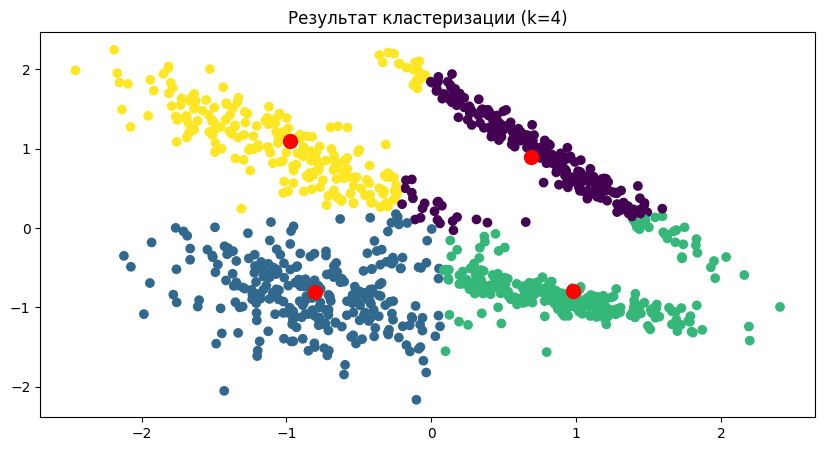

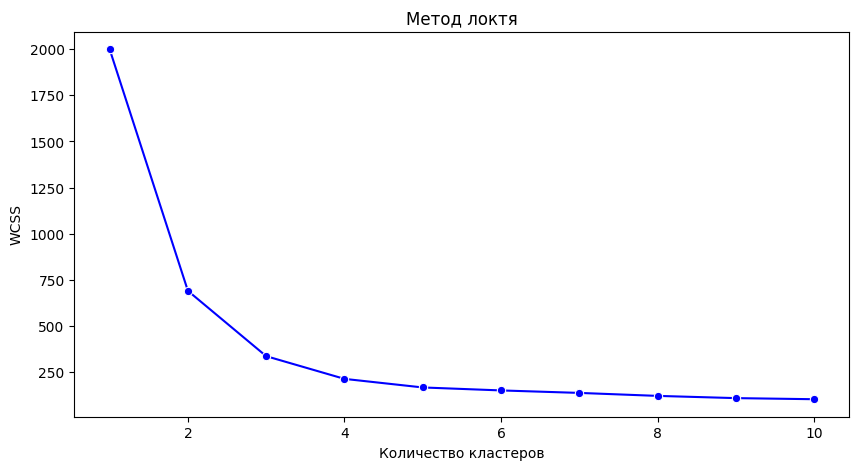

Наилучшее число кластеров 3
silhouette_score = 0.5734
rand_score = 0.8255
Кластер 0: число наблюдений 213
Кластер 1: число наблюдений 408
Кластер 2: число наблюдений 379


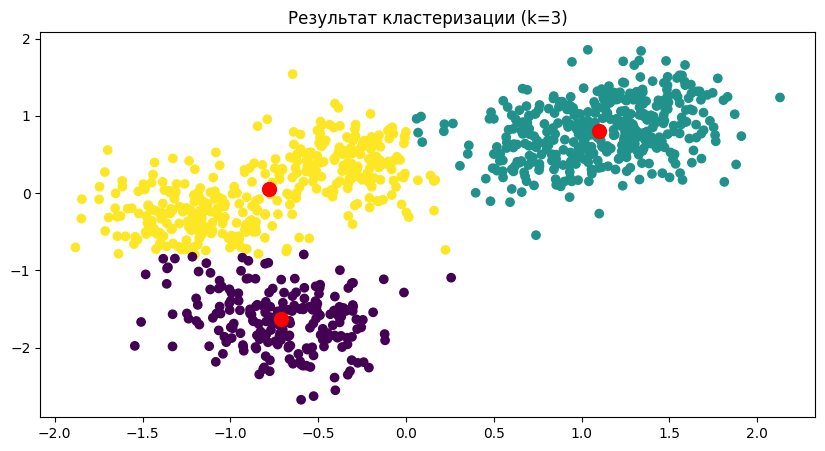

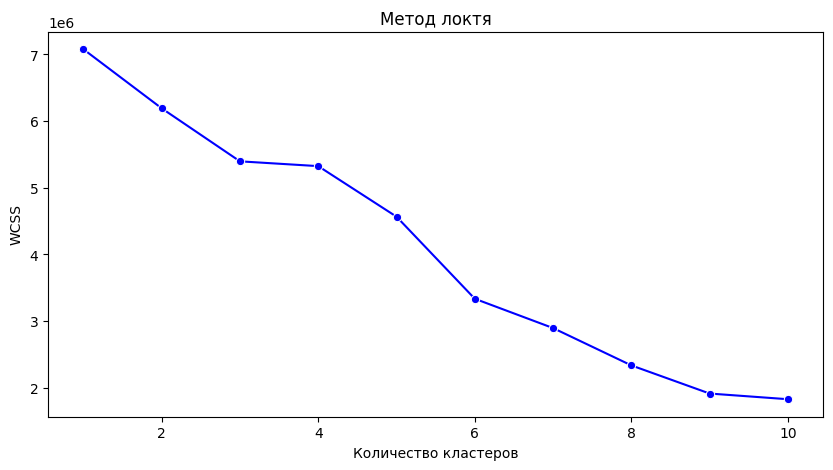

Наилучшее число кластеров 6
silhouette_score = 0.3126
rand_score = 0.3964
Кластер 0: число наблюдений 440066
Кластер 1: число наблюдений 236121
Кластер 2: число наблюдений 35799
Кластер 3: число наблюдений 48382
Кластер 4: число наблюдений 77234
Кластер 5: число наблюдений 47192


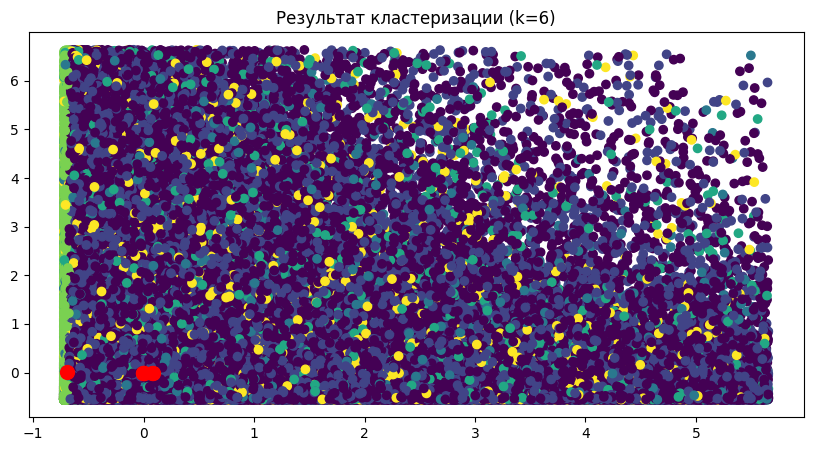

In [8]:
x = [x_1, x_2, x_3]
y = [y_1, y_2, y_3]

for j in range(len(x)):
    data = x[j]
    wcss_lst = []       # внутрикластерная сумма квадратов – within cluster sum of squares (wcss)
    for i in range(1, 11):
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=81)
        kmeans.fit(data)
        wcss_lst.append(kmeans.inertia_)

    plt.figure(figsize=(10, 5))
    sns.lineplot(x=range(1, 11), y=wcss_lst, marker='o', color='blue')
    plt.title("Метод локтя")
    plt.xlabel("Количество кластеров")
    plt.ylabel("WCSS")
    plt.show()

    kl = KneeLocator(range(1, 11), wcss_lst, curve='convex', direction='decreasing')
    elbow = kl.elbow
    print(f"Наилучшее число кластеров {elbow}")

    kmeans = KMeans(n_clusters=elbow, random_state=81)
    labels = kmeans.fit_predict(data)

    if len(data) > 50_000:
        idx_sample = np.random.choice(len(data), 20000, replace=False)
        sample_data = data.iloc[idx_sample]
        sample_labels = labels[idx_sample]
        sample_y = y[j][idx_sample] if isinstance(y[j], np.ndarray) else y[j].iloc[idx_sample]
        
        sil_score = silhouette_score(sample_data, sample_labels)
        r_score = rand_score(sample_y, sample_labels)
    else:
        sil_score = silhouette_score(data, labels)
        r_score = rand_score(y[j], labels)

    print(f"silhouette_score = {round(sil_score, 4)}")
    print(f"rand_score = {round(r_score, 4)}")

    results.append({
        'Algorithm': 'k-Means',
        'Data': dataset_names[j],
        'Silhouette Score': round(sil_score, 4),
        'Rand Score': round(r_score, 4)
    })
   
    unique, counts = np.unique(labels, return_counts=True)
    for key, value in zip(unique, counts):
        print(f"Кластер {key}: число наблюдений {value}")

    data['cluster_id'] = labels

    plt.figure(figsize=(10, 5))
    plt.scatter(data.iloc[:,0], data.iloc[:,1], c=kmeans.labels_)
    plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='red')
    plt.title(f"Результат кластеризации (k={elbow})")
    plt.show()
    

In [9]:
res = pd.DataFrame(results)
res

,Algorithm,Data,Silhouette Score,Rand Score
0,k-Means,make_classification,0.4899,0.8923
1,k-Means,make_blobs,0.5734,0.8255
2,k-Means,credit_card_fraud,0.3126,0.3964
